# 中国省级可再生能源月度数据分析：标准答案

本 Notebook 是为第一次独立数据分析项目准备的**完整参考答案**。它包含：

1. 数据读取与基本观察；
2. 重复值、缺失值、类别不统一、日期格式和异常值处理；
3. 2019—2025 年新能源发展趋势分析；
4. 省份与能源结构比较；
5. 增长率、季节性、资源条件、政策与投资分析；
6. 图表保存、清洗数据导出和结论自动生成。

> 数据是教学用途的合成数据，不代表任何官方统计结果。

## 推荐使用方式

不要一口气把所有代码复制到一个代码框。请按照 Notebook 顺序逐格运行：

- 先读每个 Markdown 框；
- 再运行其下方代码；
- 观察输出；
- 修改一个条件或参数，重新运行；
- 确认理解后再进入下一节。

你当前不需要脱离工具默写整份代码。重点是理解：

> **任务是什么 → 为什么这样处理 → 代码输入是什么 → 输出说明什么。**

## 0. 项目目录和数据文件

推荐把 Notebook 和 CSV 文件放在同一文件夹：

```text
renewable-energy-data-analysis/
├─ renewable_energy_data_analysis_standard_answer.ipynb
├─ renewable_energy_practice_raw.csv
└─ outputs/
```

下面的代码会依次查找：

1. Notebook 当前目录；
2. `data/raw/`；
3. 本次生成文件所在的 `/mnt/data/`。

找到文件后会自动读取。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 尽量兼容常见中文字体。若本机没有中文字体，图中中文可能显示为方框，
# 但不影响数据计算。
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
    "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

DATA_FILENAME = "renewable_energy_practice_raw.csv"

data_candidates = [
    Path.cwd() / DATA_FILENAME,
    Path.cwd() / "data" / "raw" / DATA_FILENAME,
    Path("/mnt/data") / DATA_FILENAME,
]

data_path = next((p for p in data_candidates if p.exists()), None)

if data_path is None:
    searched = "\n".join(str(p) for p in data_candidates)
    raise FileNotFoundError(
        f"没有找到 {DATA_FILENAME}。\n请把 CSV 与 Notebook 放在同一文件夹。\n已搜索：\n{searched}"
    )

OUTPUT_DIR = Path.cwd() / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("数据文件：", data_path)
print("输出目录：", OUTPUT_DIR.resolve())

数据文件： e:\trae\项目文件\python\123\renewable_energy_practice_raw.csv
输出目录： E:\trae\项目文件\python\123\outputs


# 1. 读取数据

这里使用 `pd.read_csv()` 读取 CSV。

- `encoding="utf-8-sig"`：兼容带 BOM 的中文 CSV；
- `df_raw`：始终保留原始数据，不直接修改；
- `df`：后面用于清洗和分析。

In [2]:
df_raw = pd.read_csv(data_path, encoding="utf-8-sig")
df = df_raw.copy()

print("原始数据形状：", df.shape)
display(df.head(10))

原始数据形状： (1518, 17)


,record_id,date,year,month,province,region,energy_type,installed_capacity_mw,generation_gwh,utilization_hours,average_temperature_c,precipitation_mm,wind_speed_m_s,solar_radiation_kwh_m2,grid_connection_rate_pct,investment_million_cny,policy_support_level
0,RE00440,2021-01-01,2021,1,内蒙古,华北,风电,"32,701.34","7,117.02",241.53,-3.34,5.57,7.60,106.76,91.97,"1,779.74",中
1,RE00919,2023-04-01,2023,4,四川,西南,光伏,"5,305.44",557.97,116.94,14.93,83.02,4.15,133.26,92.06,219.55,中
2,RE01352,2025-04-01,2025,4,四川,西南,风电,"5,996.96",823.83,141.40,13.14,90.63,4.48,126.08,94.53,290.89,高
3,RE01175,2024-06-01,2024,6,云南,西南,风电,"5,216.88",682.56,133.48,22.47,83.02,3.57,200.22,94.91,222.00,中
4,RE00012,2019-01-01,2019,1,新疆,西北,水电,"1,087.95",123.81,123.06,-0.86,28.06,7.64,110.29,91.79,43.38,低
5,RE00554,2021-07-01,2021,7,江苏,华东,风电,"10,728.78","1,281.65",129.18,25.16,122.79,4.00,182.51,91.45,432.85,中
6,RE01389,2025-06-01,2025,6,四川,西南,水电,"60,029.65","12,691.83",217.79,24.21,125.36,4.68,138.77,98.55,"1,007.05",中
7,RE00311,2020-06-01,2020,6,云南,西南,风电,"3,298.17",395.18,135.85,25.97,91.39,2.93,174.74,90.26,214.45,低
8,RE00550,2021-07-01,2021,7,新疆,西北,光伏,"18,113.64","3,053.95",182.64,19.55,37.49,4.73,200.51,91.55,966.76,中
9,RE00504,2021-04-01,2021,4,广东,华南,水电,"15,975.06","2,397.83",168.94,24.25,92.91,4.98,154.57,90.61,387.06,低


## 1.1 初步观察

第一次拿到陌生数据时，先回答：

- 有多少行、多少列？
- 每个字段叫什么？
- 各列的数据类型是什么？
- 哪些列有缺失值？
- 是否存在重复记录？
- 数值的大致范围是否合理？

In [3]:
print("数据行数、列数：", df.shape)
print("\n字段名：")
print(df.columns.tolist())

print("\n数据类型与非空数量：")
df.info()

print("\n每列缺失值数量：")
display(df.isna().sum().to_frame("missing_count"))

print("\n完全重复的记录数：", df.duplicated().sum())

print("\n数值型字段描述性统计：")
display(df.describe().T)

数据行数、列数： (1518, 17)

字段名：
['record_id', 'date', 'year', 'month', 'province', 'region', 'energy_type', 'installed_capacity_mw', 'generation_gwh', 'utilization_hours', 'average_temperature_c', 'precipitation_mm', 'wind_speed_m_s', 'solar_radiation_kwh_m2', 'grid_connection_rate_pct', 'investment_million_cny', 'policy_support_level']

数据类型与非空数量：
<class 'pandas.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   record_id                 1518 non-null   str    
 1   date                      1518 non-null   str    
 2   year                      1518 non-null   int64  
 3   month                     1518 non-null   int64  
 4   province                  1518 non-null   str    
 5   region                    1518 non-null   str    
 6   energy_type               1518 non-null   str    
 7   installed_capacity_mw     1514 non-null   float64
 8   gene

,missing_count
record_id,0
date,0
year,0
month,0
province,0
region,0
energy_type,0
installed_capacity_mw,4
generation_gwh,7
utilization_hours,0



完全重复的记录数： 6

数值型字段描述性统计：


,count,mean,std,min,25%,50%,75%,max
year,"1,518.00","2,022.00",2.00,"2,019.00","2,020.00","2,022.00","2,024.00","2,025.00"
month,"1,518.00",6.50,3.45,1.00,4.00,7.00,9.00,12.00
installed_capacity_mw,"1,514.00","18,172.39","17,807.48",491.11,"3,963.58","12,465.28","27,573.74","62,334.44"
generation_gwh,"1,511.00","2,812.12","3,160.13",6.11,480.54,"1,606.44","4,022.17","27,926.20"
utilization_hours,"1,518.00",148.99,39.30,55.00,119.89,142.25,174.12,258.67
average_temperature_c,"1,514.00",15.12,9.55,-6.99,7.78,15.13,22.58,36.23
precipitation_mm,"1,511.00",68.66,43.77,-18.40,33.93,61.10,102.12,188.89
wind_speed_m_s,"1,518.00",5.07,1.58,1.91,3.97,4.83,5.90,24.80
solar_radiation_kwh_m2,"1,518.00",137.04,39.45,46.23,105.55,133.50,167.57,240.98
grid_connection_rate_pct,"1,515.00",92.74,2.71,85.95,90.80,92.71,94.65,105.70


## 1.2 类别和日期的初步检查

`value_counts()` 可以发现：

- “四川”和“四川省”是否同时存在；
- “光伏”和“太阳能”是否被当成不同类别；
- 日期是否存在多种格式。

这一步先发现问题，不急着修改。

In [4]:
print("省份类别及频数：")
display(df["province"].value_counts(dropna=False).to_frame("count"))

print("能源类型及频数：")
display(df["energy_type"].value_counts(dropna=False).to_frame("count"))

print("日期样例：")
display(df["date"].drop_duplicates().sample(20, random_state=42).to_frame("date_sample"))

省份类别及频数：


,count
province,
新疆,253
江苏,253
内蒙古,251
云南,251
四川,250
广东,250
广东省,3
内蒙古自治区,2
云南省,2


能源类型及频数：


,count
energy_type,
水电,506
光伏,504
风电,499
风能,7
水力发电,1
太阳能,1


日期样例：


,date_sample
143,2020-04-01
26,2021-09-01
168,2025-02-01
170,2023-05-01
0,2021-01-01
32,2021-11-01
63,2019-05-01
65,2022-03-01
11,2022-06-01
69,2021-05-01


# 2. 数据清洗

我们建立一个 `cleaning_log`，记录每一步处理了多少条数据。

标准答案采用以下原则：

1. 原始数据不覆盖；
2. 每一步处理都可以解释；
3. 异常值不直接“看着不顺眼就删”；
4. 优先使用业务范围和变量间关系识别异常；
5. 清洗后执行完整性检查。

In [5]:
cleaning_log = []

def log_step(step, affected_rows, note):
    cleaning_log.append({
        "step": step,
        "affected_rows": int(affected_rows),
        "note": note,
    })

## 2.1 删除完全重复记录

这里使用 `drop_duplicates()`。

注意：重复值处理不能只看 `record_id`。标准答案先删除整行完全相同的重复记录。

In [6]:
before = len(df)
df = df.drop_duplicates().copy()
removed = before - len(df)

log_step("删除完全重复记录", removed, "使用整行完全一致作为判断标准")
print("删除重复记录数量：", removed)
print("删除后数据形状：", df.shape)

删除重复记录数量： 6
删除后数据形状： (1512, 17)


## 2.2 统一省份和能源类别名称

统一后的目标类别为：

- 省份：四川、云南、内蒙古、新疆、江苏、广东；
- 能源：光伏、风电、水电。

映射字典的优点是：规则清晰、便于检查、方便以后补充。

In [7]:
province_mapping = {
    "四川省": "四川",
    "云南省": "云南",
    "内蒙古自治区": "内蒙古",
    "新疆维吾尔自治区": "新疆",
    "江苏省": "江苏",
    "广东省": "广东",
}

energy_mapping = {
    "太阳能": "光伏",
    "风能": "风电",
    "水力发电": "水电",
}

province_changed = df["province"].isin(province_mapping).sum()
energy_changed = df["energy_type"].isin(energy_mapping).sum()

df["province"] = df["province"].replace(province_mapping)
df["energy_type"] = df["energy_type"].replace(energy_mapping)

log_step("统一省份名称", province_changed, "将省、自治区全称映射为统一简称")
log_step("统一能源类型", energy_changed, "太阳能→光伏，风能→风电，水力发电→水电")

print("清洗后的省份类别：", sorted(df["province"].dropna().unique()))
print("清洗后的能源类别：", sorted(df["energy_type"].dropna().unique()))

清洗后的省份类别： ['云南', '内蒙古', '四川', '广东', '新疆', '江苏']
清洗后的能源类别： ['光伏', '水电', '风电']


## 2.3 统一日期格式

原数据可能包含：

```text
2021-03-01
2021/03/01
2021年03月
```

先把中文年月和斜杠格式转换成统一字符串，再使用 `pd.to_datetime()`。

In [8]:
def parse_month_date(value):
    if pd.isna(value):
        return pd.NaT

    text = str(value).strip()
    text = text.replace("/", "-")
    text = text.replace("年", "-")
    text = text.replace("月", "-01")

    return pd.to_datetime(text, errors="coerce")

original_date_text = df["date"].astype(str).copy()
df["date"] = df["date"].apply(parse_month_date)

date_parse_failed = df["date"].isna().sum()
date_format_changed = (
    original_date_text.str.contains(r"/|年|月", regex=True, na=False)
).sum()

log_step("统一日期格式", date_format_changed, "统一转换为 pandas datetime")
log_step("日期解析失败", date_parse_failed, "解析失败的日期需要人工检查")

# 以解析后的日期为准，重新生成 year 和 month
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("日期解析失败数量：", date_parse_failed)
print("日期范围：", df["date"].min(), "至", df["date"].max())
display(df[["date", "year", "month"]].head())

日期解析失败数量： 0
日期范围： 2019-01-01 00:00:00 至 2025-12-01 00:00:00


,date,year,month
0,2021-01-01,2021,1
1,2023-04-01,2023,4
2,2025-04-01,2025,4
3,2024-06-01,2024,6
4,2019-01-01,2019,1


## 2.4 将数值字段转换为数值类型

`pd.to_numeric(errors="coerce")` 会把无法转换的内容变成缺失值，便于后续统一检查。

In [9]:
numeric_columns = [
    "installed_capacity_mw",
    "generation_gwh",
    "utilization_hours",
    "average_temperature_c",
    "precipitation_mm",
    "wind_speed_m_s",
    "solar_radiation_kwh_m2",
    "grid_connection_rate_pct",
    "investment_million_cny",
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

display(df[numeric_columns].dtypes.to_frame("dtype"))

,dtype
installed_capacity_mw,float64
generation_gwh,float64
utilization_hours,float64
average_temperature_c,float64
precipitation_mm,float64
wind_speed_m_s,float64
solar_radiation_kwh_m2,float64
grid_connection_rate_pct,float64
investment_million_cny,float64


## 2.5 基于业务范围识别明显异常值

下面的规则针对**月度平均或比例数据**：

- 装机容量、发电量、利用小时、太阳辐射和投资额不能为负；
- 降水量不能为负；
- 并网率应在 0%—100%；
- 月平均风速大于 20 m/s 在这份教学数据中视为异常。

发现异常后先改为缺失值，后面统一插值，而不是直接删除整行。

In [10]:
domain_rules = {
    "installed_capacity_mw": (df["installed_capacity_mw"] <= 0),
    "generation_gwh": (df["generation_gwh"] <= 0),
    "utilization_hours": (df["utilization_hours"] <= 0),
    "precipitation_mm": (df["precipitation_mm"] < 0),
    "wind_speed_m_s": (
        (df["wind_speed_m_s"] < 0) |
        (df["wind_speed_m_s"] > 20)
    ),
    "solar_radiation_kwh_m2": (df["solar_radiation_kwh_m2"] <= 0),
    "grid_connection_rate_pct": (
        (df["grid_connection_rate_pct"] < 0) |
        (df["grid_connection_rate_pct"] > 100)
    ),
    "investment_million_cny": (df["investment_million_cny"] < 0),
}

for col, mask in domain_rules.items():
    count = int(mask.fillna(False).sum())
    if count > 0:
        df.loc[mask, col] = np.nan
    log_step(f"{col} 业务范围异常", count, "异常值转为缺失值，后续按时间插值")

domain_summary = pd.DataFrame([
    {"column": col, "invalid_count": int(mask.fillna(False).sum())}
    for col, mask in domain_rules.items()
])

display(domain_summary)

,column,invalid_count
0,installed_capacity_mw,0
1,generation_gwh,0
2,utilization_hours,0
3,precipitation_mm,1
4,wind_speed_m_s,1
5,solar_radiation_kwh_m2,0
6,grid_connection_rate_pct,1
7,investment_million_cny,0


## 2.6 利用变量之间的一致性识别发电量异常

理论上：

\[
\text{发电量} \approx
\text{装机容量}\times
\text{利用小时}\div1000\times
\text{并网率}
\]

这里计算：

```text
实际发电量 / 理论估算发电量
```

若比值小于 0.5 或大于 1.5，说明该记录与其他字段严重不一致。在本教学数据中将其标记为异常。

这比简单使用箱线图删除所有“大数值”更合理，因为大型水电省份本来就可能具有很高的发电量。

In [11]:
expected_generation = (
    df["installed_capacity_mw"]
    * df["utilization_hours"]
    / 1000
    * df["grid_connection_rate_pct"]
    / 100
)

generation_consistency_ratio = df["generation_gwh"] / expected_generation

generation_outlier_mask = (
    (generation_consistency_ratio < 0.5) |
    (generation_consistency_ratio > 1.5)
) & generation_consistency_ratio.notna()

generation_outlier_count = int(generation_outlier_mask.sum())

generation_outlier_examples = df.loc[
    generation_outlier_mask,
    [
        "record_id", "date", "province", "energy_type",
        "installed_capacity_mw", "utilization_hours",
        "grid_connection_rate_pct", "generation_gwh"
    ]
].copy()

generation_outlier_examples["expected_generation_gwh"] =expected_generation[
    generation_outlier_mask
]
generation_outlier_examples["actual_expected_ratio"] = generation_consistency_ratio[
    generation_outlier_mask
]

display(generation_outlier_examples)

df.loc[generation_outlier_mask, "generation_gwh"] = np.nan

log_step(
    "发电量内部一致性异常",
    generation_outlier_count,
    "实际/理论估算比值不在 0.5—1.5，转为缺失值"
)

print("识别到的发电量异常记录数：", generation_outlier_count)

,record_id,date,province,energy_type,installed_capacity_mw,utilization_hours,grid_connection_rate_pct,generation_gwh,expected_generation_gwh,actual_expected_ratio
72,RE00033,2019-02-01,江苏,水电,492.81,109.91,90.07,6.11,48.79,0.13
227,RE00885,2023-02-01,四川,水电,"59,032.91",107.11,95.20,"27,926.20","6,019.51",4.64
383,RE01423,2025-08-01,四川,光伏,"7,757.99",108.75,93.98,"4,014.28",792.89,5.06
1290,RE00374,2020-09-01,江苏,风电,"9,934.42",135.29,92.70,"5,765.00","1,245.91",4.63
1491,RE00753,2022-06-01,江苏,水电,579.11,162.82,93.25,10.87,87.93,0.12


识别到的发电量异常记录数： 5


## 2.7 缺失值处理

由于数据是按月连续记录，标准答案采用：

1. 按“省份 + 能源类型 + 日期”排序；
2. 同一省份和能源类型内部做线性插值；
3. 若仍有缺失，用组内中位数填补；
4. 最后才使用全体中位数兜底。

这里没有使用简单的全局平均数，因为不同省份、不同能源类型的数量级差异很大。

In [12]:
missing_before = df[numeric_columns].isna().sum().to_frame("before")

df = df.sort_values(
    ["province", "energy_type", "date", "record_id"]
).reset_index(drop=True)

group_keys = ["province", "energy_type"]

for col in numeric_columns:
    df[col] = df.groupby(group_keys)[col].transform(
        lambda series: series.interpolate(method="linear", limit_direction="both")
    )

for col in numeric_columns:
    group_median = df.groupby(group_keys)[col].transform("median")
    df[col] = df[col].fillna(group_median)
    df[col] = df[col].fillna(df[col].median())

missing_after = df[numeric_columns].isna().sum().to_frame("after")
missing_comparison = missing_before.join(missing_after)

filled_count = int(missing_comparison["before"].sum() - missing_comparison["after"].sum())
log_step("数值缺失值填补", filled_count, "组内线性插值→组内中位数→全局中位数")

display(missing_comparison)

,before,after
installed_capacity_mw,4,0
generation_gwh,12,0
utilization_hours,0,0
average_temperature_c,4,0
precipitation_mm,7,0
wind_speed_m_s,1,0
solar_radiation_kwh_m2,0,0
grid_connection_rate_pct,4,0
investment_million_cny,3,0


## 2.8 清洗结果验证

清洗完成后检查：

- 是否仍有重复记录；
- 是否仍有缺失值；
- 省份和能源类别是否统一；
- 日期是否连续；
- 每个“月份 × 省份 × 能源类型”是否只有一条记录；
- 理论上应该有多少条数据。

In [13]:
key_columns = ["date", "province", "energy_type"]
key_duplicate_count = df.duplicated(subset=key_columns).sum()

validation = pd.Series({
    "清洗后总行数": len(df),
    "总字段数": df.shape[1],
    "完全重复记录数": df.duplicated().sum(),
    "时间-省份-能源重复数": key_duplicate_count,
    "全部字段缺失值总数": int(df.isna().sum().sum()),
    "省份数量": df["province"].nunique(),
    "能源类型数量": df["energy_type"].nunique(),
    "最早日期": df["date"].min(),
    "最晚日期": df["date"].max(),
}, name="validation")

display(validation.to_frame())

print("每个省份—能源类型的记录数：")
display(
    df.groupby(["province", "energy_type"])
      .size()
      .unstack()
)

if key_duplicate_count > 0:
    print("警告：仍存在业务主键重复，请继续检查。")
else:
    print("通过：每个月份、每个省份、每种能源只有一条记录。")

,validation
清洗后总行数,1512
总字段数,17
完全重复记录数,0
时间-省份-能源重复数,0
全部字段缺失值总数,0
省份数量,6
能源类型数量,3
最早日期,2019-01-01 00:00:00
最晚日期,2025-12-01 00:00:00


每个省份—能源类型的记录数：


energy_type,光伏,水电,风电
province,,,
云南,84,84,84
内蒙古,84,84,84
四川,84,84,84
广东,84,84,84
新疆,84,84,84
江苏,84,84,84


通过：每个月份、每个省份、每种能源只有一条记录。


## 2.9 查看清洗日志并保存数据

清洗日志是项目 README 和面试介绍的重要材料。

清洗后的数据输出到：

```text
outputs/renewable_energy_clean.csv
```

In [14]:
cleaning_log_df = pd.DataFrame(cleaning_log)
display(cleaning_log_df)

clean_data_path = OUTPUT_DIR / "renewable_energy_clean.csv"
cleaning_log_path = TABLE_DIR / "cleaning_log.csv"

df.to_csv(clean_data_path, index=False, encoding="utf-8-sig")
cleaning_log_df.to_csv(cleaning_log_path, index=False, encoding="utf-8-sig")

print("清洗后数据已保存：", clean_data_path.resolve())
print("清洗日志已保存：", cleaning_log_path.resolve())

,step,affected_rows,note
0,删除完全重复记录,6,使用整行完全一致作为判断标准
1,统一省份名称,10,将省、自治区全称映射为统一简称
2,统一能源类型,9,太阳能→光伏，风能→风电，水力发电→水电
3,统一日期格式,12,统一转换为 pandas datetime
4,日期解析失败,0,解析失败的日期需要人工检查
5,installed_capacity_mw 业务范围异常,0,异常值转为缺失值，后续按时间插值
6,generation_gwh 业务范围异常,0,异常值转为缺失值，后续按时间插值
7,utilization_hours 业务范围异常,0,异常值转为缺失值，后续按时间插值
8,precipitation_mm 业务范围异常,1,异常值转为缺失值，后续按时间插值
9,wind_speed_m_s 业务范围异常,1,异常值转为缺失值，后续按时间插值


清洗后数据已保存： E:\trae\项目文件\python\123\outputs\renewable_energy_clean.csv
清洗日志已保存： E:\trae\项目文件\python\123\outputs\tables\cleaning_log.csv


# 3. 清洗后数据概览

先给项目建立一个简洁的数据画像。

In [15]:
overview = pd.Series({
    "记录数": len(df),
    "开始时间": df["date"].min().strftime("%Y-%m"),
    "结束时间": df["date"].max().strftime("%Y-%m"),
    "月份数": df["date"].nunique(),
    "省份数": df["province"].nunique(),
    "能源类型数": df["energy_type"].nunique(),
    "总发电量_GWh": df["generation_gwh"].sum(),
    "平均并网率_%": df["grid_connection_rate_pct"].mean(),
    "总投资额_百万元": df["investment_million_cny"].sum(),
}, name="value")

display(overview.to_frame())

,value
记录数,1512
开始时间,2019-01
结束时间,2025-12
月份数,84
省份数,6
能源类型数,3
总发电量_GWh,"4,233,391.49"
平均并网率_%,92.72
总投资额_百万元,"1,152,915.97"


# 4. 问题一：2019—2025 年三类新能源总体如何变化？

注意两个口径：

- **年度发电量**：把一年 12 个月、所有省份的发电量相加；
- **年末装机容量**：装机容量是某个时间点的存量，不能把 12 个月直接相加，因此取每年 12 月的装机容量。

In [16]:
annual_generation = (
    df.groupby(["year", "energy_type"], as_index=False)["generation_gwh"]
      .sum()
)

year_end_capacity = (
    df.sort_values("date")
      .groupby(["year", "province", "energy_type"], as_index=False)
      .tail(1)
      .groupby(["year", "energy_type"], as_index=False)["installed_capacity_mw"]
      .sum()
)

annual_generation_pivot = annual_generation.pivot(
    index="year", columns="energy_type", values="generation_gwh"
)

year_end_capacity_pivot = year_end_capacity.pivot(
    index="year", columns="energy_type", values="installed_capacity_mw"
)

print("年度发电量（GWh）：")
display(annual_generation_pivot)

print("年末装机容量（MW）：")
display(year_end_capacity_pivot)

年度发电量（GWh）：


energy_type,光伏,水电,风电
year,,,
2019,"76,547.93","214,128.80","138,321.11"
2020,"93,763.30","218,088.97","156,961.71"
2021,"113,404.07","229,480.76","182,716.03"
2022,"139,911.06","244,981.63","211,653.77"
2023,"167,878.83","249,953.66","242,801.60"
2024,"203,677.52","256,830.51","269,253.72"
2025,"245,553.96","265,768.18","311,714.37"


年末装机容量（MW）：


energy_type,光伏,水电,风电
year,,,
2019,"56,650.12","121,839.62","72,271.79"
2020,"69,059.81","122,682.09","82,062.66"
2021,"81,070.76","125,321.80","92,466.38"
2022,"97,499.86","129,032.01","102,688.67"
2023,"116,176.73","135,368.33","115,658.15"
2024,"141,050.02","138,260.77","135,215.34"
2025,"168,856.67","142,943.61","149,633.68"


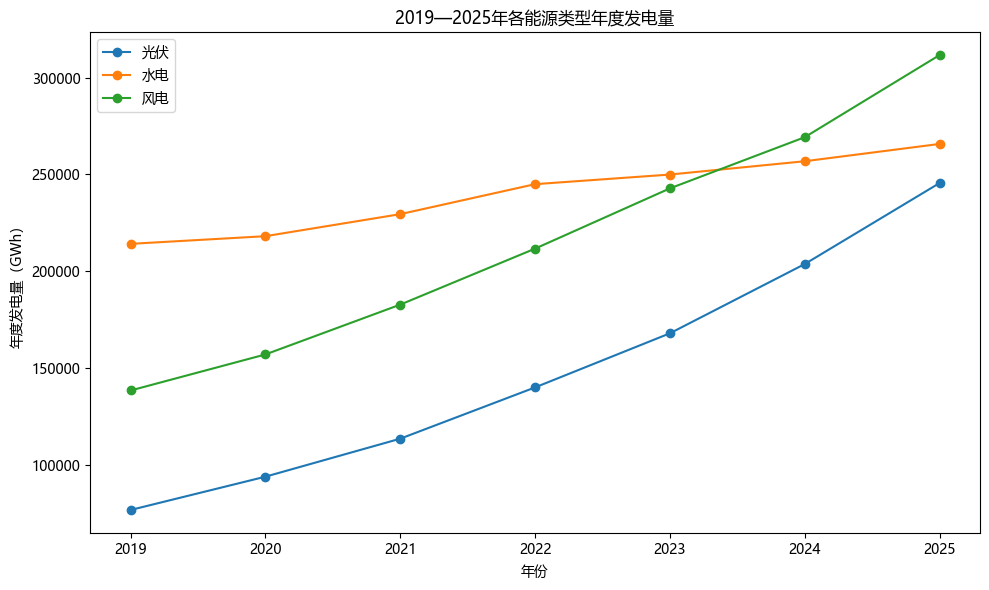

In [17]:
plt.figure(figsize=(10, 6))

for energy in annual_generation_pivot.columns:
    plt.plot(
        annual_generation_pivot.index,
        annual_generation_pivot[energy],
        marker="o",
        label=energy,
    )

plt.title("2019—2025年各能源类型年度发电量")
plt.xlabel("年份")
plt.ylabel("年度发电量（GWh）")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_annual_generation_trend.png", dpi=300)
plt.show()

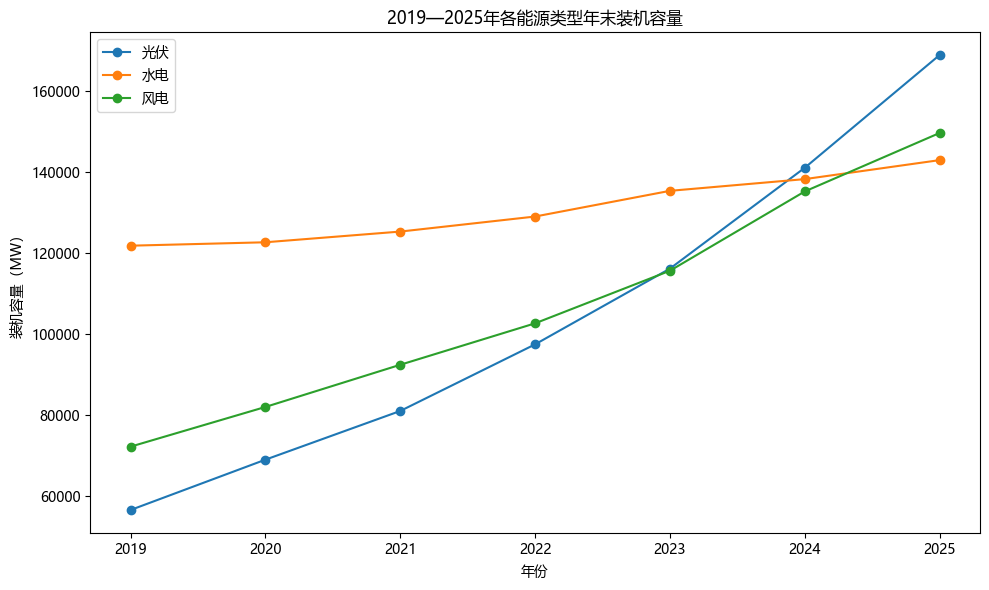

In [18]:
plt.figure(figsize=(10, 6))

for energy in year_end_capacity_pivot.columns:
    plt.plot(
        year_end_capacity_pivot.index,
        year_end_capacity_pivot[energy],
        marker="o",
        label=energy,
    )

plt.title("2019—2025年各能源类型年末装机容量")
plt.xlabel("年份")
plt.ylabel("装机容量（MW）")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_year_end_capacity_trend.png", dpi=300)
plt.show()

## 4.1 计算 2019—2025 年复合增长率

复合年增长率：

\[
CAGR=\left(\frac{V_{2025}}{V_{2019}}\right)^{1/6}-1
\]

这里 2019 到 2025 共有 6 个增长区间。

In [19]:
def calculate_cagr(series):
    series = series.dropna().sort_index()
    start_value = series.iloc[0]
    end_value = series.iloc[-1]
    periods = series.index[-1] - series.index[0]
    return (end_value / start_value) ** (1 / periods) - 1

growth_summary = []

for energy in annual_generation_pivot.columns:
    growth_summary.append({
        "energy_type": energy,
        "generation_cagr_pct": calculate_cagr(
            annual_generation_pivot[energy]
        ) * 100,
        "capacity_cagr_pct": calculate_cagr(
            year_end_capacity_pivot[energy]
        ) * 100,
    })

growth_summary_df = pd.DataFrame(growth_summary).sort_values(
    "generation_cagr_pct", ascending=False
)

display(growth_summary_df)
growth_summary_df.to_csv(
    TABLE_DIR / "energy_cagr_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,energy_type,generation_cagr_pct,capacity_cagr_pct
0,光伏,21.44,19.96
2,风电,14.50,12.90
1,水电,3.67,2.70


# 5. 问题二：2025 年不同省份的能源结构有什么差异？

这里统计 2025 年各省三类能源的发电量，并计算每个省内部的能源占比。

In [20]:
generation_2025 = (
    df[df["year"] == 2025]
    .groupby(["province", "energy_type"], as_index=False)["generation_gwh"]
    .sum()
)

province_energy_2025 = generation_2025.pivot(
    index="province",
    columns="energy_type",
    values="generation_gwh",
).fillna(0)

province_energy_share_2025 = (
    province_energy_2025
    .div(province_energy_2025.sum(axis=1), axis=0)
    * 100
)

print("2025年各省发电量（GWh）：")
display(province_energy_2025)

print("2025年各省能源结构占比（%）：")
display(province_energy_share_2025.round(2))

2025年各省发电量（GWh）：


energy_type,光伏,水电,风电
province,,,
云南,"10,769.42","102,810.55","9,358.63"
内蒙古,"52,006.92","1,643.43","146,491.41"
四川,"10,060.40","120,661.95","9,764.14"
广东,"46,233.63","37,770.81","18,975.54"
新疆,"70,727.38","1,836.91","92,904.60"
江苏,"55,756.21","1,044.53","34,220.05"


2025年各省能源结构占比（%）：


energy_type,光伏,水电,风电
province,,,
云南,8.76,83.63,7.61
内蒙古,25.99,0.82,73.19
四川,7.16,85.89,6.95
广东,44.90,36.68,18.43
新疆,42.74,1.11,56.15
江苏,61.26,1.15,37.60


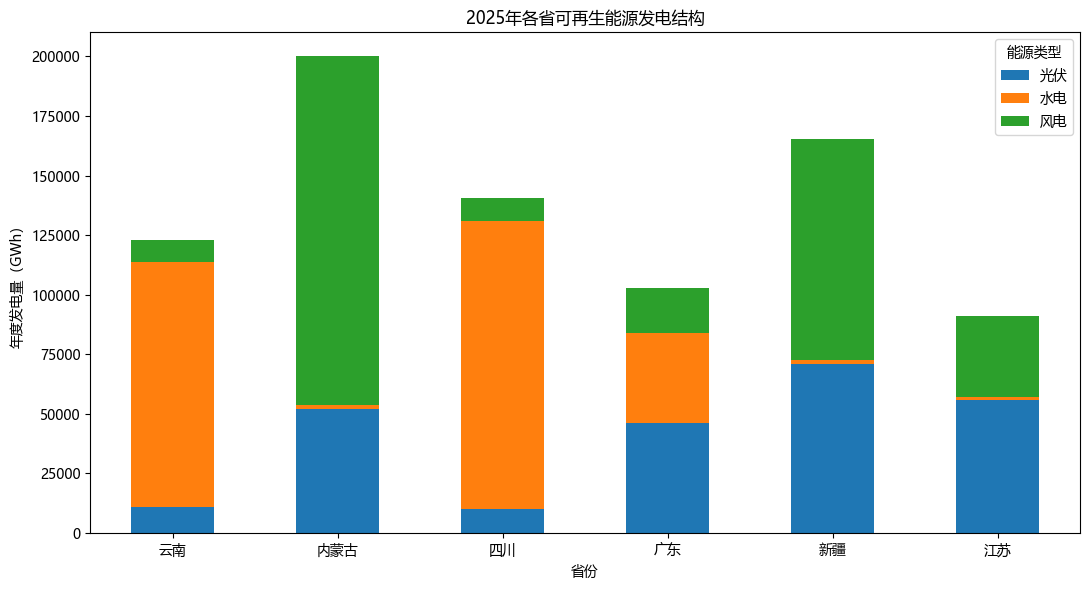

In [21]:
province_energy_2025.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
)

plt.title("2025年各省可再生能源发电结构")
plt.xlabel("省份")
plt.ylabel("年度发电量（GWh）")
plt.xticks(rotation=0)
plt.legend(title="能源类型")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_province_energy_structure_2025.png", dpi=300)
plt.show()

## 5.1 找出每个省份的主导能源

`idxmax(axis=1)` 返回每一行最大值所在的列名。

In [22]:
dominant_energy = pd.DataFrame({
    "dominant_energy": province_energy_share_2025.idxmax(axis=1),
    "dominant_share_pct": province_energy_share_2025.max(axis=1),
}).sort_values("dominant_share_pct", ascending=False)

display(dominant_energy)

,dominant_energy,dominant_share_pct
province,,
四川,水电,85.89
云南,水电,83.63
内蒙古,风电,73.19
江苏,光伏,61.26
新疆,风电,56.15
广东,光伏,44.90


# 6. 问题三：哪些省份和能源类型增长最快？

先计算年度发电量，再按“省份 + 能源类型”计算同比增长率。

`pct_change()` 的结果是相邻年份之间的增长比例。

In [40]:
province_energy_annual = (
    df.groupby(
        ["year", "province", "energy_type"],
        as_index=False
    )["generation_gwh"]
    .sum()
    .sort_values(["province", "energy_type", "year"])
)
print(province_energy_annual)
province_energy_annual["yoy_growth_pct"] = (
    province_energy_annual
    .groupby(["province", "energy_type"])["generation_gwh"]
    .pct_change()
    * 100
)

top_growth_records = (
    province_energy_annual
    .dropna(subset=["yoy_growth_pct"])
    .sort_values("yoy_growth_pct", ascending=False)
    .head(15)
)

display(top_growth_records)

     year province energy_type  generation_gwh
0    2019       云南          光伏        3,667.27
18   2020       云南          光伏        4,560.94
36   2021       云南          光伏        5,351.85
54   2022       云南          光伏        6,527.12
72   2023       云南          光伏        7,749.72
..    ...      ...         ...             ...
53   2021       江苏          风电       20,307.67
71   2022       江苏          风电       23,655.64
89   2023       江苏          风电       26,266.82
107  2024       江苏          风电       29,920.74
125  2025       江苏          风电       34,220.05

[126 rows x 4 columns]


,year,province,energy_type,generation_gwh,yoy_growth_pct
99,2024,广东,光伏,"37,064.91",27.33
111,2025,内蒙古,光伏,"52,006.92",26.59
60,2022,四川,光伏,"5,856.53",26.29
30,2020,新疆,光伏,"26,632.73",26.18
69,2022,江苏,光伏,"33,857.01",25.66
117,2025,广东,光伏,"46,233.63",24.74
50,2021,新疆,风电,"55,660.25",24.43
84,2023,新疆,光伏,"49,023.57",24.37
18,2020,云南,光伏,"4,560.94",24.37
39,2021,内蒙古,光伏,"23,046.45",23.92


单一年份增长率可能受短期波动影响，因此再比较 2019—2025 年复合增长率。

In [24]:
province_energy_cagr_rows = []

for (province, energy), group in province_energy_annual.groupby(
    ["province", "energy_type"]
):
    series = group.set_index("year")["generation_gwh"].sort_index()
    province_energy_cagr_rows.append({
        "province": province,
        "energy_type": energy,
        "generation_cagr_pct": calculate_cagr(series) * 100,
    })

province_energy_cagr = (
    pd.DataFrame(province_energy_cagr_rows)
    .sort_values("generation_cagr_pct", ascending=False)
)

display(province_energy_cagr)

,province,energy_type,generation_cagr_pct
12,新疆,光伏,22.33
3,内蒙古,光伏,22.33
9,广东,光伏,21.90
6,四川,光伏,20.10
15,江苏,光伏,19.85
0,云南,光伏,19.67
5,内蒙古,风电,15.12
17,江苏,风电,14.47
14,新疆,风电,14.33
11,广东,风电,14.21


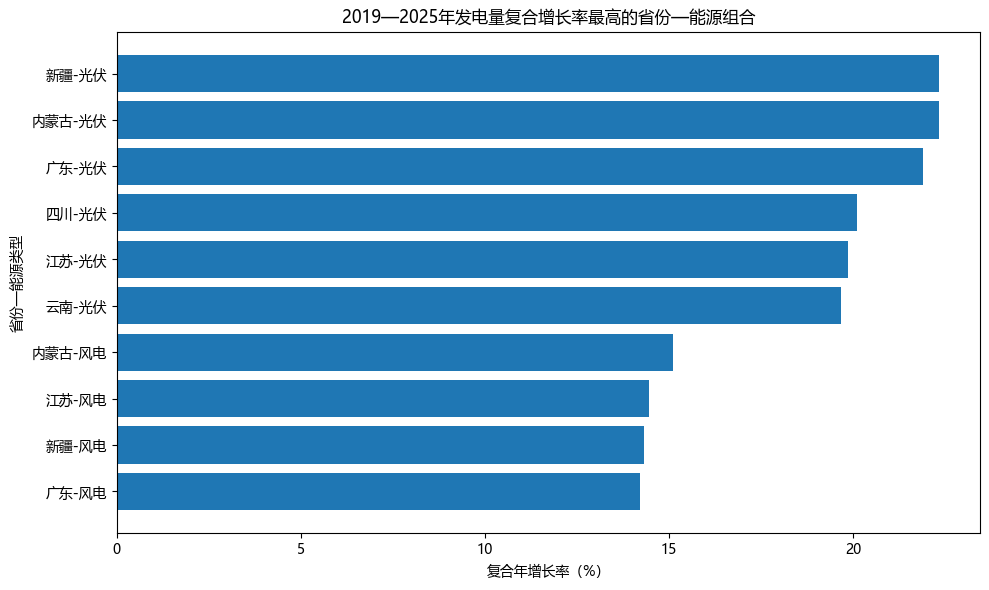

In [25]:
top_cagr = province_energy_cagr.head(10).copy()
top_cagr["label"] = (
    top_cagr["province"] + "-" + top_cagr["energy_type"]
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_cagr["label"][::-1],
    top_cagr["generation_cagr_pct"][::-1],
)
plt.title("2019—2025年发电量复合增长率最高的省份—能源组合")
plt.xlabel("复合年增长率（%）")
plt.ylabel("省份—能源类型")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_top_cagr.png", dpi=300)
plt.show()

# 7. 问题四：光伏、风电和水电是否存在月度季节性？

直接比较发电量容易受装机容量增长影响。

因此这里使用**利用小时数**观察季节性，它比原始发电量更能反映资源条件和运行效率。

In [26]:
monthly_utilization = (
    df.groupby(["month", "energy_type"], as_index=False)["utilization_hours"]
    .mean()
)

monthly_utilization_pivot = monthly_utilization.pivot(
    index="month",
    columns="energy_type",
    values="utilization_hours",
)

display(monthly_utilization_pivot)

energy_type,光伏,水电,风电
month,,,
1,118.95,117.70,198.57
2,129.80,109.71,195.91
3,138.68,112.42,197.52
4,151.73,125.27,184.47
5,155.77,139.21,168.91
6,156.02,161.94,151.15
7,152.02,174.42,141.24
8,139.52,177.00,140.15
9,128.04,171.39,143.04


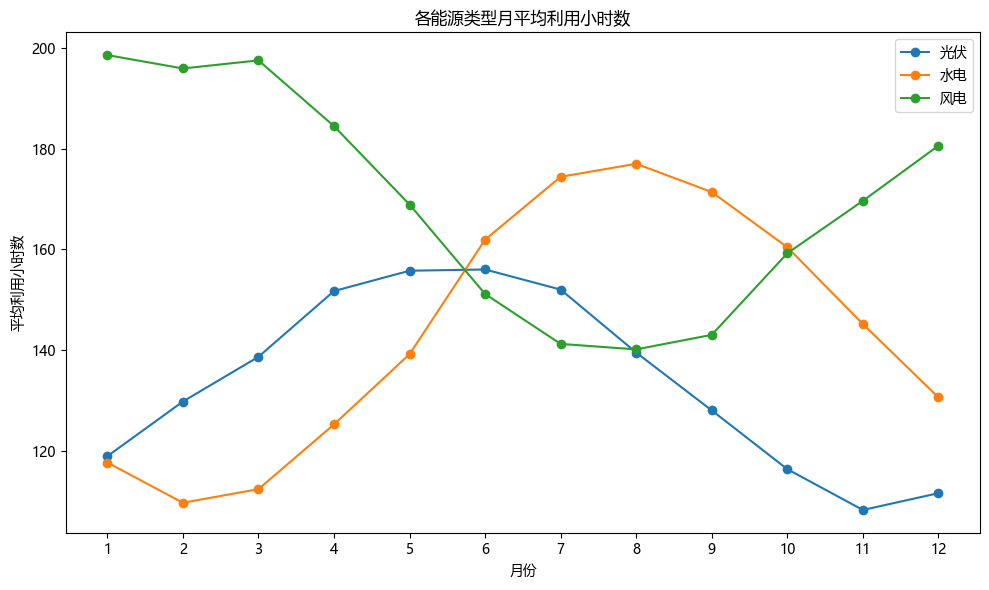

In [27]:
plt.figure(figsize=(10, 6))

for energy in monthly_utilization_pivot.columns:
    plt.plot(
        monthly_utilization_pivot.index,
        monthly_utilization_pivot[energy],
        marker="o",
        label=energy,
    )

plt.title("各能源类型月平均利用小时数")
plt.xlabel("月份")
plt.ylabel("平均利用小时数")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_monthly_seasonality.png", dpi=300)
plt.show()

## 7.1 每种能源的高峰月份和低谷月份

In [28]:
seasonality_summary = []

for energy in monthly_utilization_pivot.columns:
    series = monthly_utilization_pivot[energy]
    seasonality_summary.append({
        "energy_type": energy,
        "peak_month": int(series.idxmax()),
        "peak_utilization_hours": series.max(),
        "low_month": int(series.idxmin()),
        "low_utilization_hours": series.min(),
        "peak_low_gap": series.max() - series.min(),
    })

seasonality_summary_df = pd.DataFrame(seasonality_summary)
display(seasonality_summary_df)

,energy_type,peak_month,peak_utilization_hours,low_month,low_utilization_hours,peak_low_gap
0,光伏,6,156.02,11,108.28,47.74
1,水电,8,177.00,2,109.71,67.29
2,风电,1,198.57,8,140.15,58.42


# 8. 问题五：装机容量与发电量之间的关系是否稳定？

先计算相关系数，再绘制散点图。

注意：

- 相关性不等于因果关系；
- 装机容量越大，一般发电量越大；
- 利用小时、资源条件和并网率也会影响发电量。

In [29]:
capacity_generation_corr = (
    df.groupby("energy_type")
      .apply(
          lambda group: group[
              ["installed_capacity_mw", "generation_gwh"]
          ].corr().iloc[0, 1]
      )
      .rename("pearson_correlation")
      .to_frame()
)

display(capacity_generation_corr)

,pearson_correlation
energy_type,
光伏,0.95
水电,0.96
风电,0.97


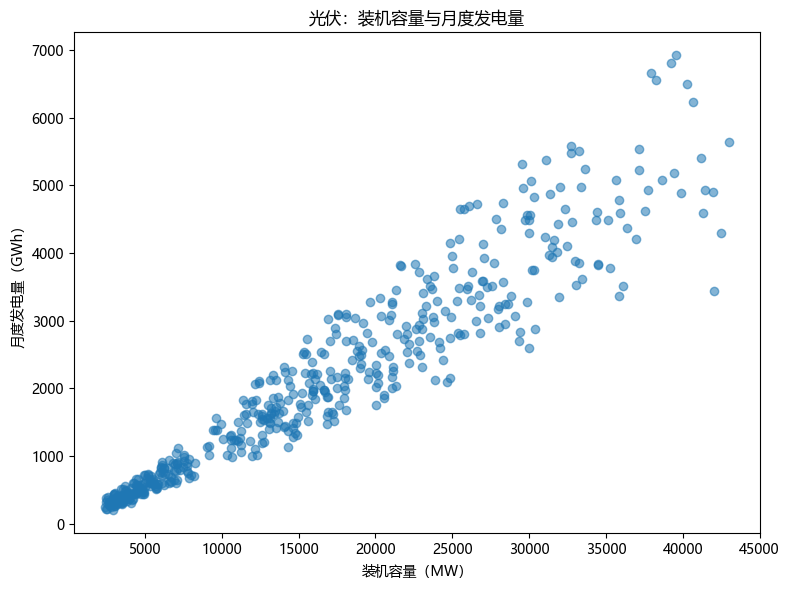

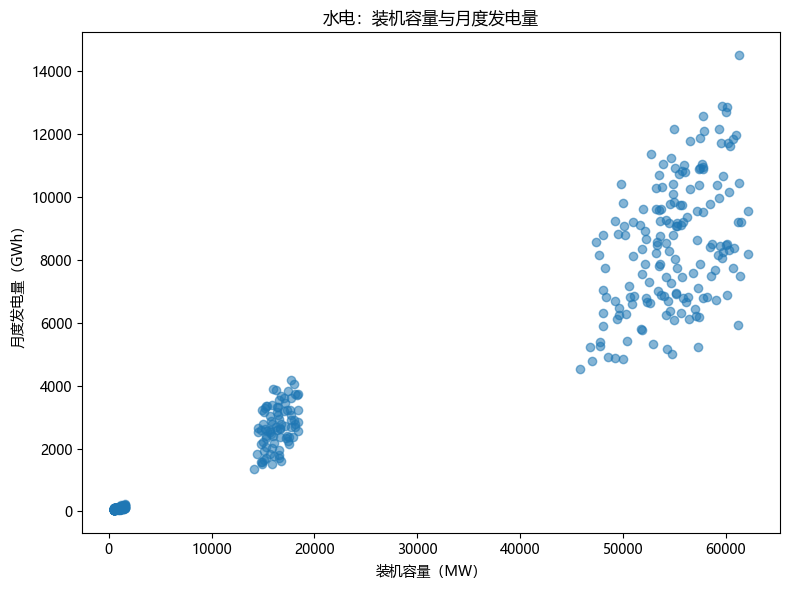

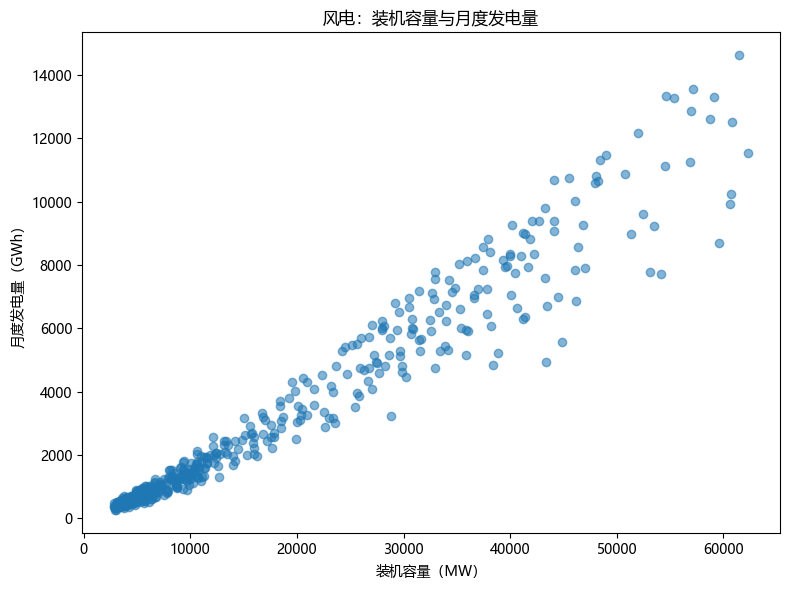

In [30]:
for energy in sorted(df["energy_type"].unique()):
    subset = df[df["energy_type"] == energy]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        subset["installed_capacity_mw"],
        subset["generation_gwh"],
        alpha=0.55,
    )
    plt.title(f"{energy}：装机容量与月度发电量")
    plt.xlabel("装机容量（MW）")
    plt.ylabel("月度发电量（GWh）")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"06_capacity_generation_{energy}.png",
        dpi=300,
    )
    plt.show()

## 8.1 识别相对偏离明显的记录

为了避免不同规模造成影响，重新计算：

```text
实际发电量 / 基于容量、利用小时、并网率估算的发电量
```

清洗后该比值应该接近 1。下面展示偏离 1 最大的记录，作为进一步检查对象，而不是自动判定为错误。

In [31]:
expected_generation_clean = (
    df["installed_capacity_mw"]
    * df["utilization_hours"]
    / 1000
    * df["grid_connection_rate_pct"]
    / 100
)

df["generation_consistency_ratio"] = (
    df["generation_gwh"] / expected_generation_clean
)

largest_deviations = (
    df.assign(
        deviation_from_one=(
            df["generation_consistency_ratio"] - 1
        ).abs()
    )
    .sort_values("deviation_from_one", ascending=False)
    .head(15)
    [
        [
            "date", "province", "energy_type",
            "generation_gwh", "generation_consistency_ratio",
            "deviation_from_one"
        ]
    ]
)

display(largest_deviations)

,date,province,energy_type,generation_gwh,generation_consistency_ratio,deviation_from_one
1167,2025-04-01,新疆,水电,115.59,0.55,0.45
1193,2020-06-01,新疆,风电,"3,372.53",1.15,0.15
637,2023-02-01,四川,水电,"6,720.17",1.12,0.12
1345,2019-02-01,江苏,水电,54.25,1.11,0.11
1153,2024-02-01,新疆,水电,88.24,0.89,0.11
283,2021-08-01,内蒙古,光伏,"2,117.86",0.92,0.08
583,2025-08-01,四川,光伏,853.19,1.08,0.08
735,2024-04-01,四川,风电,880.66,1.07,0.07
179,2019-12-01,云南,风电,505.46,1.06,0.06
1278,2020-07-01,江苏,光伏,"2,542.44",1.05,0.05


# 9. 问题六：资源条件与对应能源表现有什么关系？

直接用资源变量和发电量做相关分析，会被装机容量干扰。

例如：

- 新疆装机大，因此即使某月太阳辐射一般，发电量仍可能高；
- 小规模省份即使资源较好，绝对发电量也可能较低。

所以标准答案把资源变量与**利用小时数**进行相关分析：

- 光伏：太阳辐射；
- 风电：风速；
- 水电：降水量。

In [32]:
resource_pairs = {
    "光伏": "solar_radiation_kwh_m2",
    "风电": "wind_speed_m_s",
    "水电": "precipitation_mm",
}

resource_correlation_rows = []

for energy, resource_col in resource_pairs.items():
    subset = df[df["energy_type"] == energy]
    corr = subset[[resource_col, "utilization_hours"]].corr().iloc[0, 1]

    resource_correlation_rows.append({
        "energy_type": energy,
        "resource_variable": resource_col,
        "correlation_with_utilization_hours": corr,
    })

resource_correlation_df = pd.DataFrame(resource_correlation_rows)
display(resource_correlation_df)

,energy_type,resource_variable,correlation_with_utilization_hours
0,光伏,solar_radiation_kwh_m2,0.90
1,风电,wind_speed_m_s,0.95
2,水电,precipitation_mm,0.95


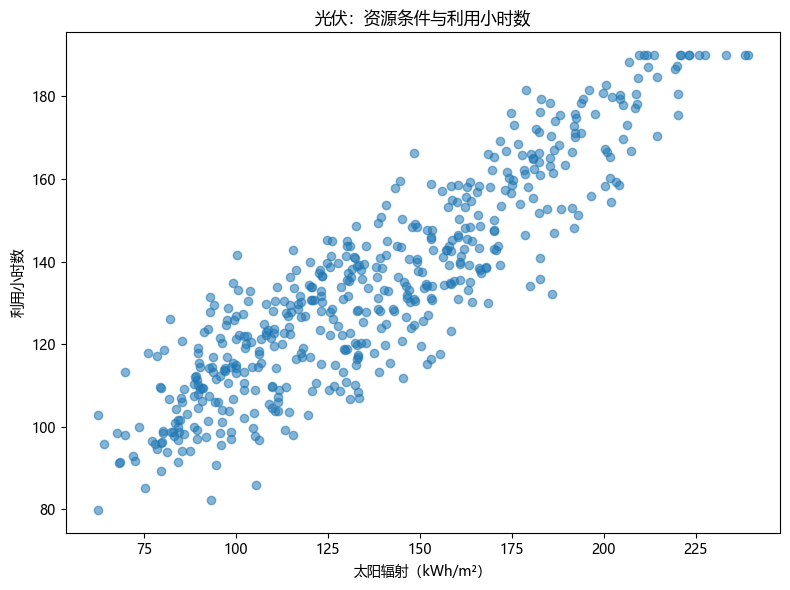

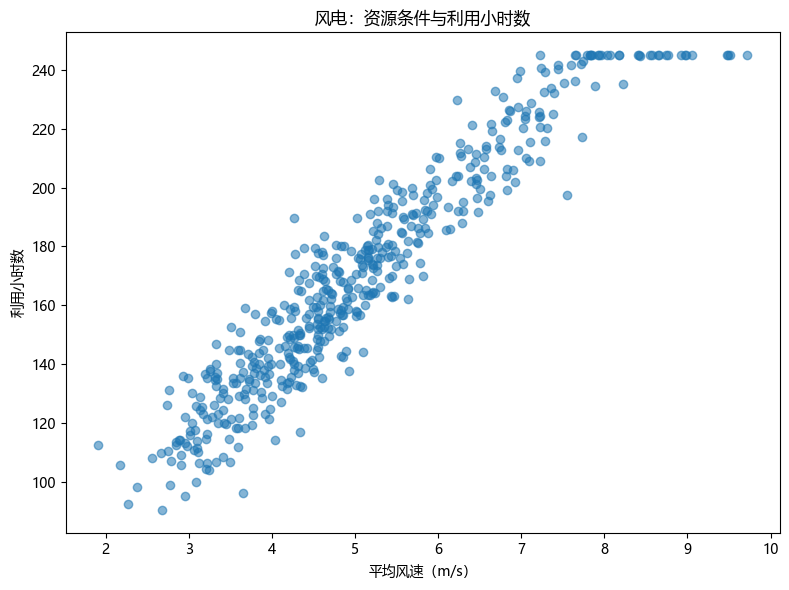

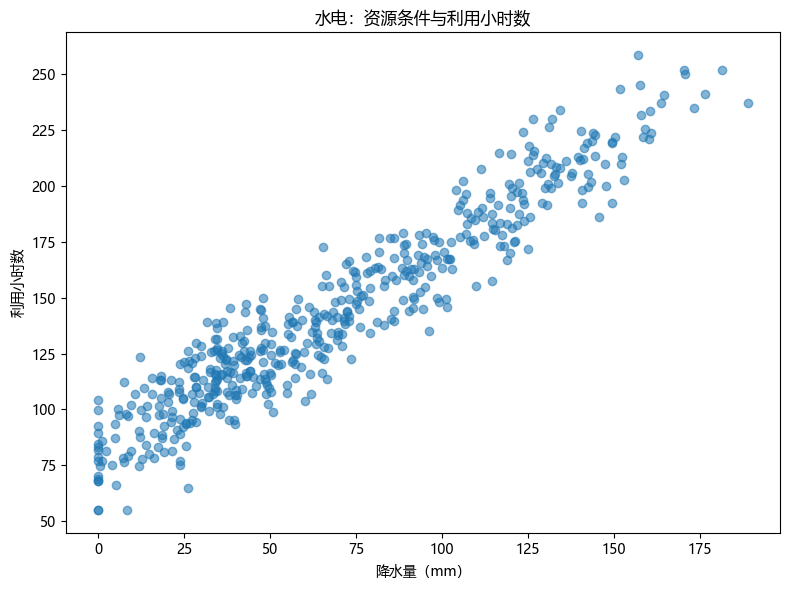

In [33]:
resource_label = {
    "solar_radiation_kwh_m2": "太阳辐射（kWh/m²）",
    "wind_speed_m_s": "平均风速（m/s）",
    "precipitation_mm": "降水量（mm）",
}

for energy, resource_col in resource_pairs.items():
    subset = df[df["energy_type"] == energy]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        subset[resource_col],
        subset["utilization_hours"],
        alpha=0.55,
    )
    plt.title(f"{energy}：资源条件与利用小时数")
    plt.xlabel(resource_label[resource_col])
    plt.ylabel("利用小时数")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"07_resource_utilization_{energy}.png",
        dpi=300,
    )
    plt.show()

# 10. 问题七：并网率、投资和政策支持等级有何差异？

这是描述性比较，不能直接得出“政策导致发电增长”的因果结论。

因为政策等级还可能与年份、地区和能源类型共同变化。

In [34]:
policy_summary = (
    df.groupby("policy_support_level")
      .agg(
          record_count=("record_id", "count"),
          average_grid_rate_pct=(
              "grid_connection_rate_pct", "mean"
          ),
          average_investment_million_cny=(
              "investment_million_cny", "mean"
          ),
          average_generation_gwh=("generation_gwh", "mean"),
          average_capacity_mw=("installed_capacity_mw", "mean"),
      )
      .reindex(["低", "中", "高"])
)

display(policy_summary)

,record_count,average_grid_rate_pct,average_investment_million_cny,average_generation_gwh,average_capacity_mw
policy_support_level,,,,,
低,384,90.23,489.28,"2,703.59","17,887.71"
中,804,92.86,651.99,"2,394.96","15,760.79"
高,324,95.35,"1,360.59","3,918.71","24,472.01"


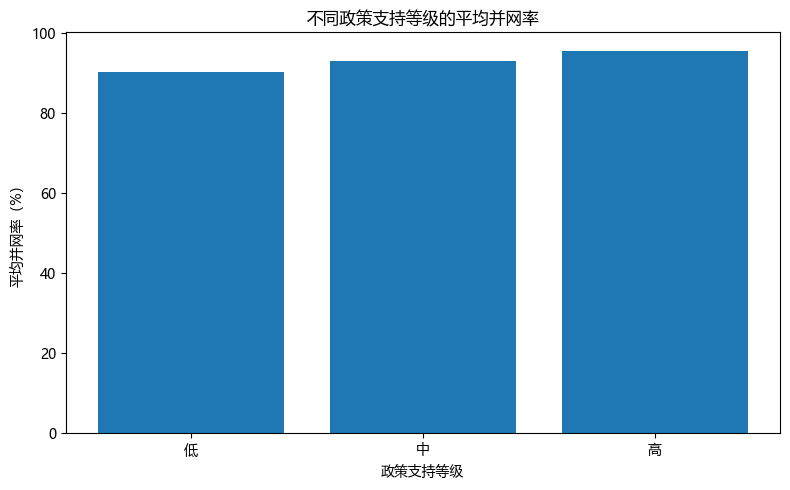

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(
    policy_summary.index,
    policy_summary["average_grid_rate_pct"],
)
plt.title("不同政策支持等级的平均并网率")
plt.xlabel("政策支持等级")
plt.ylabel("平均并网率（%）")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_policy_grid_rate.png", dpi=300)
plt.show()

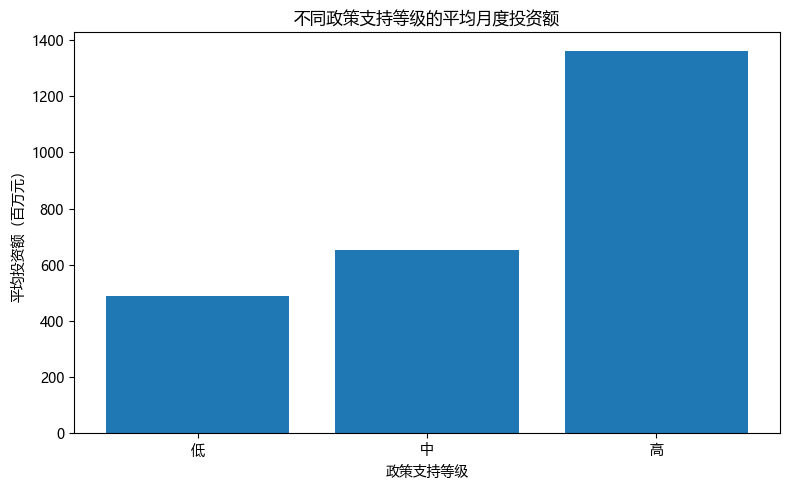

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(
    policy_summary.index,
    policy_summary["average_investment_million_cny"],
)
plt.title("不同政策支持等级的平均月度投资额")
plt.xlabel("政策支持等级")
plt.ylabel("平均投资额（百万元）")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09_policy_investment.png", dpi=300)
plt.show()

## 10.1 投资额与装机容量增量

先计算相同省份、能源类型相邻月份的装机容量变化，再分析投资额与容量增量的相关性。

注意：教学数据中的投资与扩张存在关系，但真实项目中投资可能提前或滞后于项目投产。

In [37]:
df = df.sort_values(
    ["province", "energy_type", "date"]
).reset_index(drop=True)

df["capacity_monthly_change_mw"] = (
    df.groupby(["province", "energy_type"])["installed_capacity_mw"]
      .diff()
)

investment_capacity_corr = (
    df[
        ["investment_million_cny", "capacity_monthly_change_mw"]
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)

print(
    "投资额与当月装机容量变化的 Pearson 相关系数：",
    round(investment_capacity_corr, 4),
)

投资额与当月装机容量变化的 Pearson 相关系数： 0.2248


# 11. 自动生成主要结论

下面的代码基于实际计算结果生成一组标准结论。

真正写 README 时，可以把这些结果改写成自然语言，并配上关键数值和图表。

In [38]:
generation_fastest = growth_summary_df.iloc[0]
capacity_fastest = growth_summary_df.sort_values(
    "capacity_cagr_pct", ascending=False
).iloc[0]

top_combo = province_energy_cagr.iloc[0]

dominant_text = "；".join(
    f"{province}以{row['dominant_energy']}为主，占比约{row['dominant_share_pct']:.1f}%"
    for province, row in dominant_energy.iterrows()
)

seasonality_text = "；".join(
    f"{row['energy_type']}高峰为{int(row['peak_month'])}月、低谷为{int(row['low_month'])}月"
    for _, row in seasonality_summary_df.iterrows()
)

resource_text = "；".join(
    f"{row['energy_type']}对应资源与利用小时相关系数为{row['correlation_with_utilization_hours']:.3f}"
    for _, row in resource_correlation_df.iterrows()
)

conclusions = [
    (
        f"1. 2019—2025年三类能源总体均呈扩张趋势。"
        f"发电量复合增长最快的是{generation_fastest['energy_type']}，"
        f"年均增速约为{generation_fastest['generation_cagr_pct']:.2f}%；"
        f"装机容量复合增长最快的是{capacity_fastest['energy_type']}，"
        f"年均增速约为{capacity_fastest['capacity_cagr_pct']:.2f}%。"
    ),
    (
        f"2. 省份能源结构差异明显：{dominant_text}。"
        "这说明省份间的资源禀赋和既有装机基础不同。"
    ),
    (
        f"3. 2019—2025年发电量复合增长率最高的组合为"
        f"{top_combo['province']}-{top_combo['energy_type']}，"
        f"年均增速约为{top_combo['generation_cagr_pct']:.2f}%。"
    ),
    (
        f"4. 三种能源都表现出不同程度的月度季节性：{seasonality_text}。"
        "使用利用小时而不是原始发电量，可以减少装机规模增长带来的干扰。"
    ),
    (
        "5. 装机容量与月度发电量总体呈较强正相关，"
        "但利用小时、资源条件和并网率会导致相同装机规模下的发电表现不同。"
    ),
    (
        f"6. 资源条件与利用小时之间的关系符合数据设计逻辑：{resource_text}。"
        "相关性只能说明共同变化，不能单独证明因果关系。"
    ),
    (
        f"7. 投资额与当月装机容量变化的相关系数为"
        f"{investment_capacity_corr:.3f}。"
        "真实业务中还应进一步研究投资到投产之间的时间滞后。"
    ),
    (
        "8. 原始数据包含重复记录、缺失值、类别名称不统一、日期格式不统一、"
        "超出业务范围的数值和发电量内部不一致等问题。"
        "标准答案采用可记录、可解释的规则完成清洗，而不是直接删除所有极端值。"
    ),
]

print("\n\n".join(conclusions))

1. 2019—2025年三类能源总体均呈扩张趋势。发电量复合增长最快的是光伏，年均增速约为21.44%；装机容量复合增长最快的是光伏，年均增速约为19.96%。

2. 省份能源结构差异明显：四川以水电为主，占比约85.9%；云南以水电为主，占比约83.6%；内蒙古以风电为主，占比约73.2%；江苏以光伏为主，占比约61.3%；新疆以风电为主，占比约56.1%；广东以光伏为主，占比约44.9%。这说明省份间的资源禀赋和既有装机基础不同。

3. 2019—2025年发电量复合增长率最高的组合为新疆-光伏，年均增速约为22.33%。

4. 三种能源都表现出不同程度的月度季节性：光伏高峰为6月、低谷为11月；水电高峰为8月、低谷为2月；风电高峰为1月、低谷为8月。使用利用小时而不是原始发电量，可以减少装机规模增长带来的干扰。

5. 装机容量与月度发电量总体呈较强正相关，但利用小时、资源条件和并网率会导致相同装机规模下的发电表现不同。

6. 资源条件与利用小时之间的关系符合数据设计逻辑：光伏对应资源与利用小时相关系数为0.898；风电对应资源与利用小时相关系数为0.951；水电对应资源与利用小时相关系数为0.952。相关性只能说明共同变化，不能单独证明因果关系。

7. 投资额与当月装机容量变化的相关系数为0.225。真实业务中还应进一步研究投资到投产之间的时间滞后。

8. 原始数据包含重复记录、缺失值、类别名称不统一、日期格式不统一、超出业务范围的数值和发电量内部不一致等问题。标准答案采用可记录、可解释的规则完成清洗，而不是直接删除所有极端值。


# 12. 导出主要分析表

把重要分析结果保存为 CSV，便于后续制作 README、报告或前端页面。

In [39]:
tables_to_export = {
    "annual_generation.csv": annual_generation,
    "year_end_capacity.csv": year_end_capacity,
    "energy_cagr_summary.csv": growth_summary_df,
    "province_energy_2025.csv": province_energy_2025.reset_index(),
    "province_energy_share_2025.csv": (
        province_energy_share_2025.reset_index()
    ),
    "province_energy_cagr.csv": province_energy_cagr,
    "monthly_utilization.csv": monthly_utilization,
    "resource_correlation.csv": resource_correlation_df,
    "policy_summary.csv": policy_summary.reset_index(),
}

for filename, table in tables_to_export.items():
    table.to_csv(
        TABLE_DIR / filename,
        index=False,
        encoding="utf-8-sig",
    )

print("已导出的表格：")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print("-", path.name)

print("\n已导出的图片：")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path.name)

已导出的表格：
- annual_generation.csv
- cleaning_log.csv
- energy_cagr_summary.csv
- monthly_utilization.csv
- policy_summary.csv
- province_energy_2025.csv
- province_energy_cagr.csv
- province_energy_share_2025.csv
- resource_correlation.csv
- year_end_capacity.csv

已导出的图片：
- 01_annual_generation_trend.png
- 02_year_end_capacity_trend.png
- 03_province_energy_structure_2025.png
- 04_top_cagr.png
- 05_monthly_seasonality.png
- 06_capacity_generation_光伏.png
- 06_capacity_generation_水电.png
- 06_capacity_generation_风电.png
- 07_resource_utilization_光伏.png
- 07_resource_utilization_水电.png
- 07_resource_utilization_风电.png
- 08_policy_grid_rate.png
- 09_policy_investment.png


# 13. 你需要真正掌握的代码

不要求你背下整份 Notebook，但要理解以下对应关系：

| 任务 | 主要代码 |
|---|---|
| 读取 CSV | `pd.read_csv()` |
| 查看前几行 | `df.head()` |
| 查看数据结构 | `df.info()` |
| 检查缺失值 | `df.isna().sum()` |
| 检查重复值 | `df.duplicated()` |
| 删除重复值 | `df.drop_duplicates()` |
| 类别名称替换 | `df["列"].replace(mapping)` |
| 日期转换 | `pd.to_datetime()` |
| 条件筛选 | `df[df["列"] == 条件]` |
| 分组统计 | `groupby().agg()` |
| 行列转换 | `pivot()` |
| 同比增长 | `pct_change()` |
| 组内插值 | `groupby().transform()` |
| 排序 | `sort_values()` |
| 保存 CSV | `to_csv()` |
| 绘图 | `plt.plot()`、`plt.bar()`、`plt.scatter()` |

## 你应该能够解释的关键问题

1. 为什么装机容量不能按 12 个月直接求和？
2. 为什么资源变量更适合和利用小时比较，而不是直接和发电量比较？
3. 为什么异常值先转为缺失值，而不是删除整行？
4. 为什么缺失值优先在同一省份和能源类型内部插值？
5. 为什么相关性不能直接证明因果关系？
6. `groupby()`、`pivot()`、`pct_change()` 分别解决了什么任务？

# 14. 基于标准答案的修改练习

完成标准答案后，不要再完整抄第三遍。请在这份 Notebook 上完成以下修改：

### 修改任务 A：时间范围

只分析 2022—2025 年，重新生成年度发电量趋势图。

### 修改任务 B：地区筛选

只比较西南地区的四川和云南，分析两省的能源结构差异。

### 修改任务 C：排名

找出 2025 年光伏发电量最高的 3 个省份。

### 修改任务 D：增加指标

计算：

```text
单位装机发电量 = generation_gwh / installed_capacity_mw
```

比较三类能源的平均单位装机发电量。

### 修改任务 E：复述项目

用自己的语言回答：

1. 原始数据有什么问题？
2. 你如何清洗？
3. 最重要的三条结论是什么？
4. 哪些结论只是相关性，不能解释为因果关系？

> 能完成这些修改，比脱离工具默写完整 Notebook 更重要。

# 15. 项目完成标准

当你能够做到以下内容，就可以把这个项目视为第一阶段完成：

- 能按顺序运行整份 Notebook；
- 能解释每个章节的任务；
- 能修改筛选条件、字段和图表；
- 能处理常见报错；
- 能独立完成第 14 节至少 3 个修改任务；
- 能向别人用 3—5 分钟介绍数据、清洗、分析和结论；
- 能把项目上传到 GitHub 或 Gitee，并写一份 README。

下一阶段不再学习第二套 Pandas 课程，而应进入：

> **Git与项目整理 → SQL → HTTP/JSON/API → FastAPI → 大模型API与RAG。**